FEATURES ENGINEERING 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
X = pd.read_csv('X_train.csv')
y = pd.read_csv('y_train.csv')

In [3]:
glosR_stratum = pd.read_csv("Glossaire_stratum.csv", header=None)
glosR_stratum.columns = ["STRATUM_key", "Description_stratum"]
glosR_stratum

,STRATUM_key,Description_stratum
0,ALB01,ALB - stratum 01: Urban / North / Public
1,ALB02,ALB - stratum 02: Urban / North / Private
2,ALB03,ALB - stratum 03: Urban / Center / Public
3,ALB04,ALB - stratum 04: Urban / Center / Private
4,ALB05,ALB - stratum 05: Urban / South / Public
...,...,...
1312,VNM12,VNM - stratum 12: Southern Vietnam / >50% publ...
1313,VNM13,VNM - stratum 13: Southern Vietnam / >50% publ...
1314,VNM14,VNM - stratum 14: Southern Vietnam / <50% publ...
1315,VNM15,VNM - stratum 15: Southern Vietnam / <50% publ...


In [4]:
# Extraire les 5 premiers caractères de STRATUM
X["STRATUM_key"] = X["STRATUM"].str[:5]

In [5]:
def classify(desc):
    if pd.isna(desc):
        return "Other"
    desc = desc.lower()
    public = "public" in desc
    private = ("private" in desc) or ("privé" in desc)
    if public and private:
        return "Public+Private"
    elif public:
        return "Public"
    elif private:
        return "Private"
    else:
        return "Other"

# Ajouter une colonne type dans le glossaire
glosR_stratum["SchoolType"] = glosR_stratum["Description_stratum"].apply(classify)

# Créer le dictionnaire {clé : type}
stratum_dict = dict(zip(glosR_stratum["STRATUM_key"], glosR_stratum["SchoolType"]))

In [6]:
X["SchoolType"] = X["STRATUM_key"].map(stratum_dict)

In [7]:
def onehot(label):
    if label == "Public":
        return (1,0)
    elif label == "Private":
        return (0,1)
    elif label == "Public+Private":
        return (1,1)
    else:  # Other
        return (0,0)

X[["is_public", "is_private"]] = X["SchoolType"].apply(lambda x: pd.Series(onehot(x)))

In [8]:
X

,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,...,science_q14_total_timing,science_q15_total_timing,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing,STRATUM_key,SchoolType,is_public,is_private
0,384002,2022,NLD,528.0,52800132.0,52801144.0,08MS,52800,NLD06,5280000,...,NaN,NaN,NaN,NaN,NaN,NaN,NLD06,Other,0,0
1,1118072,2018,QAZ,31.0,3100106.0,3100424.0,07MS,3100,QAZ0101,310000,...,NaN,NaN,NaN,NaN,NaN,NaN,QAZ01,Public,1,0
2,845454,2018,FRA,250.0,25000010.0,25005207.0,07MS,25000,FRA0101,2500000,...,NaN,NaN,NaN,NaN,NaN,NaN,FRA01,Other,0,0
3,1728613,2015,QES,971.0,97100240.0,97127584.0,06MS,72400,ESP1633,7241600,...,NaN,NaN,NaN,NaN,NaN,NaN,ESP16,Private,0,1
4,1083243,2018,PHL,608.0,60800071.0,60802698.0,07MS,60800,PHL0011,6080000,...,NaN,NaN,NaN,NaN,NaN,NaN,PHL00,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1155255,2018,SAU,682.0,68200049.0,68205684.0,07MS,68200,SAU0010,6820000,...,NaN,NaN,NaN,NaN,NaN,NaN,SAU00,NaN,0,0
1996,175135,2022,FIN,246.0,24600213.0,24603248.0,08MS,24600,FIN23,2460000,...,NaN,NaN,NaN,NaN,NaN,NaN,FIN23,Other,0,0
1997,1284841,2015,BRA,76.0,7600254.0,7613833.0,06MS,7600,BRA1020,760000,...,NaN,NaN,NaN,NaN,NaN,NaN,BRA10,Public,1,0
1998,482533,2022,VNM,704.0,70400150.0,70403174.0,08MS,70400,VNM11,7040000,...,NaN,NaN,NaN,NaN,NaN,NaN,VNM11,Public,1,0


Corrélation NaN_ratio vs MathScore : -0.10305756972203818
CNT
ALB    0.636376
ARE    0.575173
ARG    0.532809
AUS    0.584194
AUT    0.579391
         ...   
UKR    0.581458
URY    0.574995
USA    0.531350
UZB    0.488746
VNM    0.636197
Name: NaN_ratio, Length: 98, dtype: float64


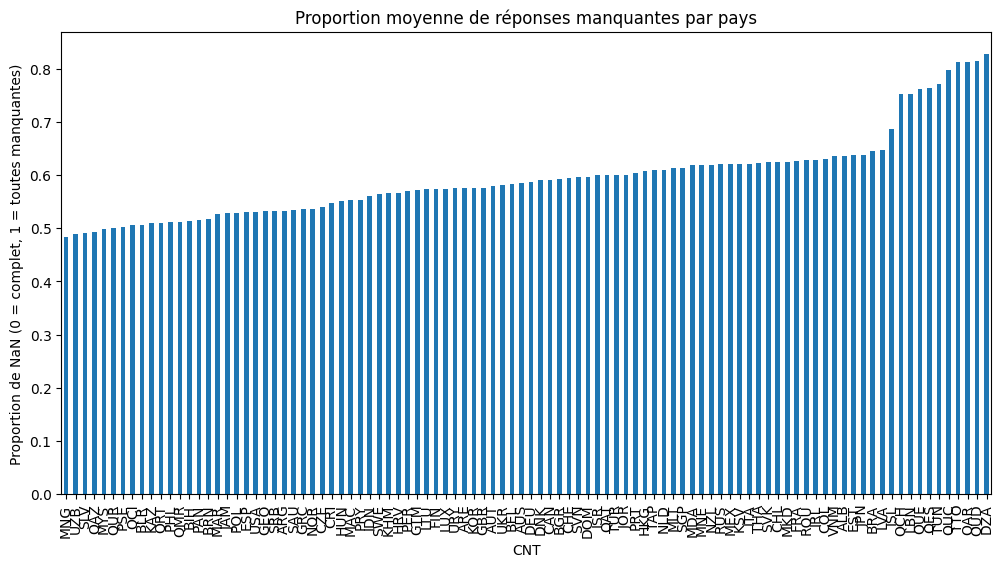

In [10]:
# Calcul de la proportion de NaN par ligne
n_cols = X.shape[1]

X["NaN_ratio"] = X.isna().sum(axis=1) / n_cols

#Fusion de NaN_ratio et CNT 
df = pd.concat([X[["NaN_ratio"]], y[["MathScore"]]], axis=1)

#Analyse globale de la corrélation
corr = df["NaN_ratio"].corr(df["MathScore"])
print("Corrélation NaN_ratio vs MathScore :", corr)

nan_by_country = X.groupby("CNT")["NaN_ratio"].mean()
print(nan_by_country)

#Ajout d'une nouvelle colonne dans X avec la moyenne des NaN dans le pays 
X["Country_Mean_NaN"] = X["CNT"].map(nan_by_country)

#Représentation graphique si jamais 
nan_by_country.sort_values().plot(kind="bar", figsize=(12,6))
plt.title("Proportion moyenne de réponses manquantes par pays")
plt.ylabel("Proportion de NaN (0 = complet, 1 = toutes manquantes)")
plt.show()

In [11]:
X

,Unnamed: 0,Year,CNT,CNTRYID,CNTSCHID,CNTSTUID,CYC,NatCen,STRATUM,SUBNATIO,...,science_q16_total_timing,science_q17_total_timing,science_q18_total_timing,science_q19_total_timing,STRATUM_key,SchoolType,is_public,is_private,NaN_ratio,Country_Mean_NaN
0,384002,2022,NLD,528.0,52800132.0,52801144.0,08MS,52800,NLD06,5280000,...,NaN,NaN,NaN,NaN,NLD06,Other,0,0,0.482315,0.609995
1,1118072,2018,QAZ,31.0,3100106.0,3100424.0,07MS,3100,QAZ0101,310000,...,NaN,NaN,NaN,NaN,QAZ01,Public,1,0,0.508039,0.493715
2,845454,2018,FRA,250.0,25000010.0,25005207.0,07MS,25000,FRA0101,2500000,...,NaN,NaN,NaN,NaN,FRA01,Other,0,0,0.511254,0.625804
3,1728613,2015,QES,971.0,97100240.0,97127584.0,06MS,72400,ESP1633,7241600,...,NaN,NaN,NaN,NaN,ESP16,Private,0,1,0.745981,0.762888
4,1083243,2018,PHL,608.0,60800071.0,60802698.0,07MS,60800,PHL0011,6080000,...,NaN,NaN,NaN,NaN,PHL00,NaN,0,0,0.511254,0.511032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1155255,2018,SAU,682.0,68200049.0,68205684.0,07MS,68200,SAU0010,6820000,...,NaN,NaN,NaN,NaN,SAU00,NaN,0,0,0.594855,0.533762
1996,175135,2022,FIN,246.0,24600213.0,24603248.0,08MS,24600,FIN23,2460000,...,NaN,NaN,NaN,NaN,FIN23,Other,0,0,0.475884,0.573687
1997,1284841,2015,BRA,76.0,7600254.0,7613833.0,06MS,7600,BRA1020,760000,...,NaN,NaN,NaN,NaN,BRA10,Public,1,0,0.784566,0.645304
1998,482533,2022,VNM,704.0,70400150.0,70403174.0,08MS,70400,VNM11,7040000,...,NaN,NaN,NaN,NaN,VNM11,Public,1,0,0.556270,0.636197


## Self-Introspection - Aureva Features Engineering

### 🔴 Risk 1 : `NaN_ratio` computed after new columns are added

`NaN_ratio` is calculated as `X.isna().sum(axis=1) / X.shape[1]` *after* the engineered columns (`STRATUM_key`, `SchoolType`, `is_public`, `is_private`) have already been appended to `X`. Since some of these new columns contain NaN values (which `SchoolType` does, as visible in the final output), they inflate the ratio artificially. The denominator also grows with each added column, making the metric inconsistent.

**How to fix it:** Compute `NaN_ratio` on the original columns only, before any feature engineering:
```python
original_cols = X.columns.tolist()  # save before adding new features
X["NaN_ratio"] = X[original_cols].isna().sum(axis=1) / len(original_cols)
```

---

### 🔴 Risk 2 : Data leakage in `Country_Mean_NaN`

`Country_Mean_NaN` is derived by grouping `X` by country and computing the mean NaN ratio. This is fine at train time, but nothing in this notebook ensures the statistic is frozen. When applied to `X_test`, if this mapping is recomputed on test data instead of reused from training, it constitutes data leakage — the model indirectly sees test-set information during training.

**How to fix it:** Save the mapping at train time and reuse it explicitly on the test set:
```python
# At train time
country_nan_map = X_train.groupby("CNT")["NaN_ratio"].mean()
X_train["Country_Mean_NaN"] = X_train["CNT"].map(country_nan_map)

# At test time — use the SAME map, never recompute
X_test["Country_Mean_NaN"] = X_test["CNT"].map(country_nan_map)
X_test["Country_Mean_NaN"].fillna(country_nan_map.mean(), inplace=True)  # handle unseen countries
```

---

### 🟡 Risk 3 : Keyword-based `SchoolType` classification is fragile

The `classify()` function detects school type by searching for the words `"public"` and `"private"` in free-text descriptions. Some strata descriptions (e.g. VNM: *">50% publicly funded"*) contain the word "public" in a nuanced way that may not cleanly map to the intended category. Any description with unexpected phrasing will be silently misclassified as `"Other"`.

**How to fix it:** After classification, manually inspect all entries that fall into `"Other"` to confirm they are genuine unknowns:
```python
print(glosR_stratum[glosR_stratum["SchoolType"] == "Other"]["Description_stratum"].unique())
```

---

### 🟡 Risk 4 : `"Other"` encoded as (0, 0) - ambiguous signal

In the `onehot()` function, the `"Other"` category (unknown school type) maps to `(is_public=0, is_private=0)`, which is identical to a school that is genuinely neither public nor private. If `"Other"` is frequent, the model cannot distinguish between true mixed schools and unclassified ones, which introduces noise.

**Fix:** Add a third binary column to make the distinction explicit:
```python
X["is_unknown"] = (X["SchoolType"] == "Other").astype(int)
```